<a href="https://colab.research.google.com/github/marcuslee6/Logistics-and-Retail-Data/blob/main/Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<Figure size 1000x400 with 0 Axes>

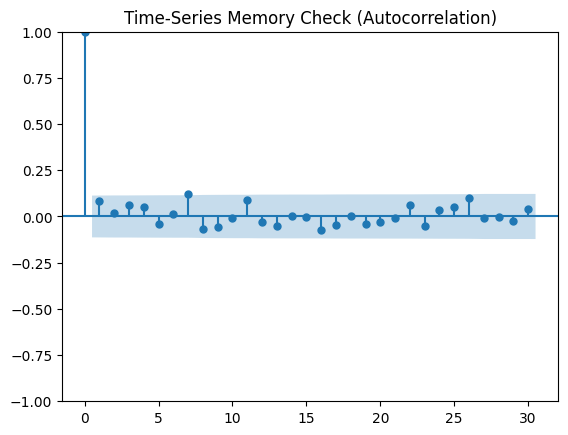

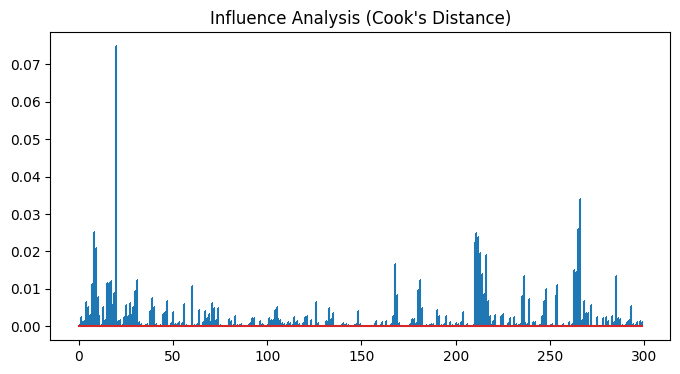

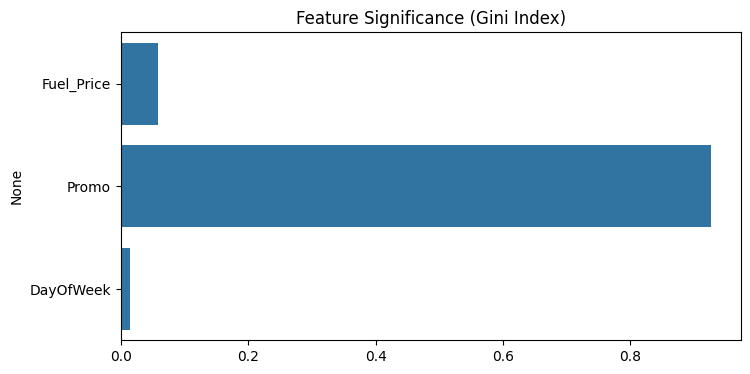

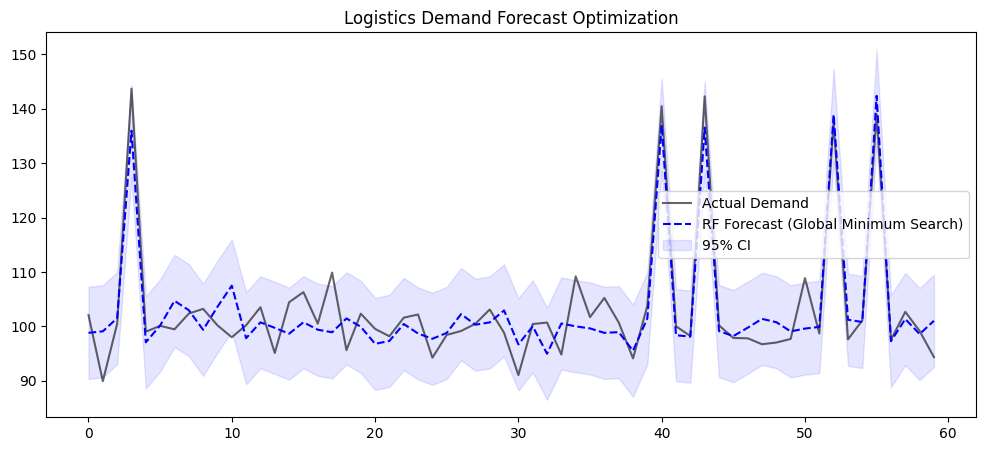

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm

# 1. DATA GENERATION: Simulating a Complex Logistics Environment
np.random.seed(42)
n_days = 300
days = pd.date_range(start='2023-01-01', periods=n_days, freq='D')

# Simulate Time-Series Memory (Autoregressive) & Volatility (GARCH Logic)
demand = np.zeros(n_days)
demand[0] = 100
for t in range(1, n_days):
# Volatility Clustering (GARCH): Shocks size depends on previous variance
  volatility = 2 + 0.15 * abs(demand[t-1] - 100)
  shock = np.random.normal(0, volatility)
# Autoregressive (AR): Current demand relies on yesterday's demand
  demand[t] = 20 + 0.8 * demand[t-1] + shock

# Add External Variables (Fuel Price and Promotion Spikes)
fuel_price = np.linspace(18, 22, n_days) + np.random.normal(0, 0.5, n_days)
promo = np.random.choice([0, 1], size=n_days, p=[0.9, 0.1])
demand = demand + (promo * 40) # These are your "Global Maxima"

# Create and Save CSV
df = pd.DataFrame({
'Date': days, 'Demand': np.round(demand, 2),
'Fuel_Price': np.round(fuel_price, 2), 'Promo': promo,
'DayOfWeek': days.dayofweek
})
df.to_csv('logistics_demand.csv', index=False)

# 2. DIAGNOSTICS: Autocorrelation (ACF)
plt.figure(figsize=(10, 4))
plot_acf(df['Demand'], lags=30)
plt.title('Time-Series Memory Check (Autocorrelation)')
plt.show()

# 3. OUTLIER DETECTION: Cook's Distance
X = df[['Fuel_Price', 'Promo', 'DayOfWeek']]
y = df['Demand']
ols_model = sm.OLS(y, sm.add_constant(X)).fit()
cooks_d = ols_model.get_influence().cooks_distance[0]

plt.figure(figsize=(8, 4))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.title("Influence Analysis (Cook's Distance)")
plt.show()

# 4. RANDOM FOREST: Bagging & Gini Index
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# RF reduces variance to find the Global Minimum error
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature Importance using Gini Index
plt.figure(figsize=(8, 4))
sns.barplot(x=rf.feature_importances_, y=X.columns)
plt.title('Feature Significance (Gini Index)')
plt.show()

# 5. FINAL FORECAST: Confidence Intervals
y_pred = rf.predict(X_test)
#root mean square error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# Calculate 95% Confidence Interval for risk management
upper_bound, lower_bound = y_pred + (1.96 * rmse), y_pred - (1.96 * rmse)

plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Demand', color='black', alpha=0.6)
plt.plot(y_pred, label='RF Forecast (Global Minimum Search)', color='blue', linestyle='--')
plt.fill_between(range(len(y_test)), lower_bound, upper_bound, color='blue', alpha=0.1, label='95% CI')
plt.legend()
plt.title('Logistics Demand Forecast Optimization')
plt.show()

